In [ ]:
"""
Quantized-tensor-train Maxwell simulation of an EM pulse in a dielectric cavity
Reference: http://ammar-hakim.org/sj/je/je6/je6-maxwell-solvers.html (if without the dielectric cavity)
"""

In [10]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys, time, glob

import numpy as np

sys.path.append('../')

from setup_.defaults import *
from setup_.configs import *

from axis import Axis
from coord.coord_sys import Coordinate
from coord.cartesian import CartesianCoordinateSpace
from grid1D import Grid1D
from field import Field, ScalarField
# from pde_vlasovEM import VlasovMaxwell
from pde_EM import Maxwell


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
save_figs = False
save_data = True
load_data = False
restart = False
restart_from_T = 0  ## to restart from an output file (vs a saved restart file)
verbose = False

use_mask = 'box'  # 'box' or None 

if restart or save_data or save_figs:
    fdir = 'data_cross/EM2/'
    os.makedirs(fdir, exist_ok=True)
    print('fdir', fdir)


fdir data_cross/EM2/


In [12]:
######################
# problem parameters #
######################

### EM paramters
permittivity = 1.0  # permittivity of free space
permeability = 1.0  # permeability of free space
eV = 1.0  # elementary charge or Joule-eV conversion factor
matl_config = UnitsConfiguration(eps0=permittivity, mu0=permeability)

## simulation box
Lx = 1.0
Ly = 1.0

## initial E field
E0 = 1.
beta = 25 if use_mask is None else 25 * 4
Ez = lambda x, y: E0 * np.exp(-beta * (x ** 2 + y ** 2))
c = 1 / np.sqrt(permittivity * permeability)

## time stepping parameters
T = 1.5   # total runtime
cfl = 0.75  # fraction of CFL step

## simulation parameters
upwind = True  # use upwinding
order = 1   # order of centered finite difference stencil (accuracy=2*order)


#########################
### dielectric cavity ###
#########################

n_refract = 100
def get_dielectric(x_vals, y_vals):
    if use_mask == 'box':
        x_mesh, y_mesh = np.meshgrid(x_vals, y_vals)
        w = 20
        mask_x = 0.5 * (np.tanh((x_vals + 0.5) * w) - np.tanh((x_vals - 0.5) * w))
        mask_y = mask_x
        mask_array = np.outer(mask_x, mask_y)
        mask_array = (1 - mask_array) * 1. / n_refract ** 2 + mask_array
    elif use_mask == 'circle':
        x_mesh, y_mesh = np.meshgrid(x_vals, y_vals)
        mask_array = float(np.sqrt(x_mesh ** 2 + y_mesh ** 2) < Lx / 2)
        mask_array = (1 - mask_array) * 1. / n_refract ** 2 + mask_array
    else:
        mask_array = None
    return mask_array


##########################
# QTT / grid parameters #
##########################

## grid resolution
q = 2   # physical dimension of each tensor core
L = 8   # number of tensor cores per dimension
K = 2   # number of dimension
npts = q ** L  # number of grid points per dimension
TN_layout = LayoutType.SEQUENTIAL   # QTT layout


##############################
## initialize Axes and Grid ##
##############################

## define coordinates (will label axes and vector components)
X = Coordinate('X', CoordinateType.X)
Y = Coordinate('Y', CoordinateType.Y)
Z = Coordinate('Z', CoordinateType.Z)

## define axis objects
x_vals = np.linspace(-Lx, Lx, npts)
y_vals = np.linspace(-Lx, Ly, npts)

ax_x = Axis(L, q, coordinate=X, xpts=x_vals)
ax_y = Axis(L, q, coordinate=Y, xpts=y_vals)

## define coordinate system
coord_sys = CartesianCoordinateSpace('cart', ax_x, ax_y, coords=[X, Y, Z])

## define grids
grid_xy = Grid1D('XY', (ax_x, ax_y), layout_type=TN_layout)


dt 0.002941176470588225 0.002941176470588225 510
dx 0.007843137254901933 dy 0.007843137254901933


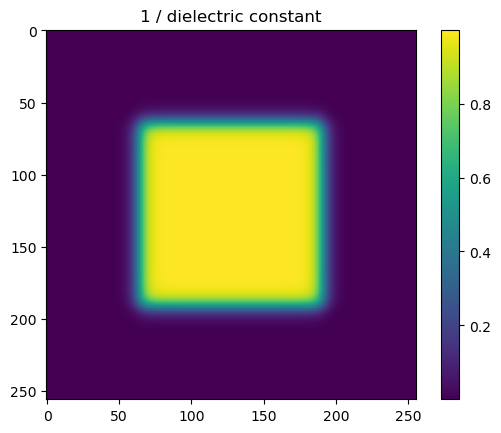

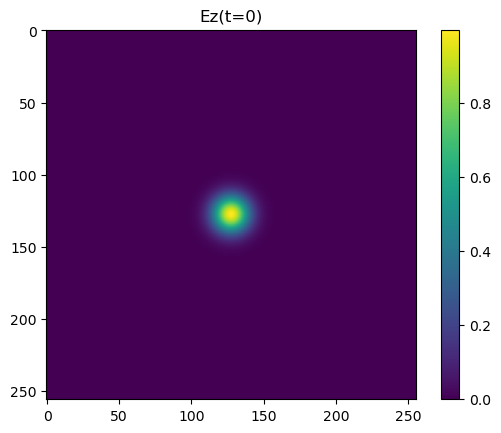

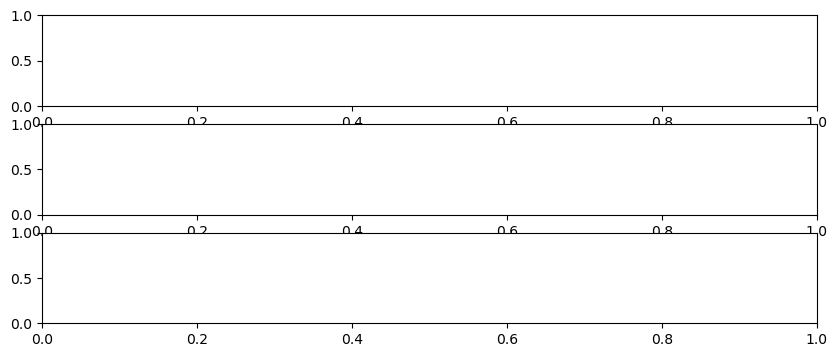

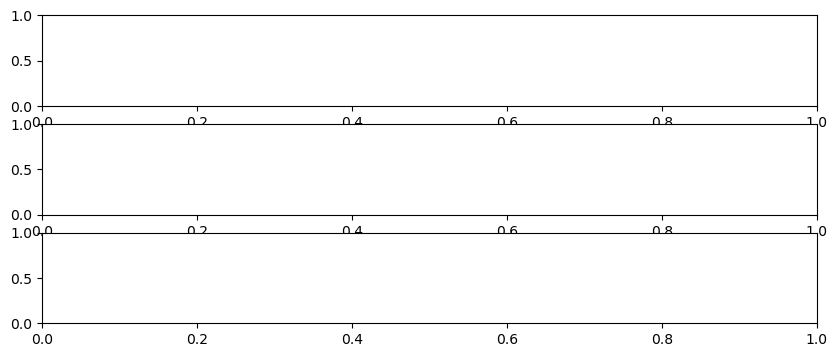

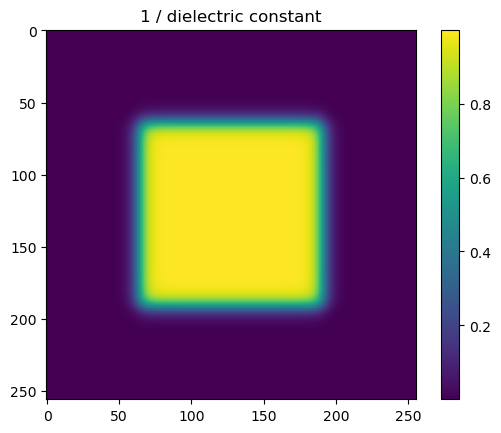

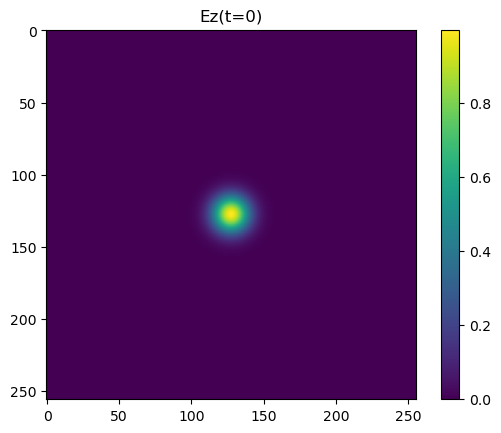

In [13]:
######################################################### 
## specify boundary conditions and spatial derivatives ##
#########################################################

if use_mask:
    # but for simplicity use PBC bc fields are all approximately zero at simulation boundaries (field is localized to cavity)
    deriv_zg = DerivativeConfiguration(left_bc=BCType.PERIODIC, order=order, fd_type=FDType.CENTER)
    deriv_zv = DerivativeConfiguration(left_bc=BCType.PERIODIC, order=order, fd_type=FDType.CENTER)
else:
    deriv_zg = DerivativeConfiguration(left_bc=BCType.ZEROGRADIENT, order=order, fd_type=FDType.CENTER)
    deriv_zv = DerivativeConfiguration(left_bc=BCType.ZEROVALUE, order=order, fd_type=FDType.CENTER)

######################
### time step info ###
######################

dx, dy = ax_x.dx, ax_y.dx
cfl_params = ((dx, dy), (c, c))
dt = cfl * cfl_limit(cfl_params)
num_tsteps = int(T / dt)
print('dt', dt, cfl * 1. / (c / ax_x.dx + c / ax_y.dx), num_tsteps)
print('dx', dx, 'dy', dy)

##########################
## field initialization ##
##########################

## define Ez 
data_x, data_y = np.meshgrid(x_vals, y_vals, indexing='ij')
init_Ez = Ez(data_x, data_y)

## define dielectric (in QTT format)
mask_array = get_dielectric(x_vals, y_vals)
eps_inv_mask = grid_xy.map_state_to_mps(mask_array) if mask_array is not None else None

if eps_inv_mask is not None:
    plt.figure()
    plt.imshow(eps_inv_mask.get_data())
    plt.title('1 / dielectric constant')
    plt.colorbar()
    # plt.show()

plt.figure()
plt.imshow(init_Ez)
plt.title('Ez(t=0)')
plt.colorbar()
plt.show()


In [24]:
def run_maxwell(te_order, tol=1.0e-14, DMAX=None):
    """
    te_order: int
        ## 31: Euler (finite volume)
        ## 331:  orthogonal td-dmrg + Euler
        ## 771:  mixed td-dmrg + Euler
        ## 441:  cross td-dmrg + Euler
    tol: singular value truncation threshold
    DMAX: maximum rank
    """

    print('run maxwell: tol', tol, 'DMAX', DMAX)
    
    #############################
    #### compression options ####
    #############################
    te_compress_E = CompressionConfiguration()
    for ci in range(1, 3):
        te_compress_E.set_compress_opts(ci, max_bond=DMAX, cutoff_mode=CUTOFF_MODE, cutoff=tol**2)
        ## set compression parameters for multiple levels (final calcs, intermediate stages)
    te_compress_B = te_compress_E
    
    ###################
    ### init fields ###
    ###################
    
    init_Ex_gtn = grid_xy.make_empty_gridTN()
    init_Ey_gtn = grid_xy.make_empty_gridTN()
    init_Ez_gtn = grid_xy.map_state_to_mps(init_Ez, ax_deriv_configs={ax_x: deriv_zv, ax_y: deriv_zv})
    
    init_Bx_gtn = grid_xy.make_empty_gridTN(ax_deriv_configs={ax_x: deriv_zv, ax_y: deriv_zg})
    init_By_gtn = grid_xy.make_empty_gridTN(ax_deriv_configs={ax_x: deriv_zg, ax_y: deriv_zv})
    
    init_E_field = Field('E', grid_xy, data={X: init_Ex_gtn, Y: init_Ey_gtn, Z: init_Ez_gtn},
                         compress_config=te_compress_E, is_sqrt=True)
    init_B_field = Field('B', grid_xy, data={X: init_Bx_gtn, Y: init_By_gtn}, compress_config=te_compress_B,
                         is_sqrt=True)
    # init_phi_field = ScalarField('phi', grid_xy, data=init_phi_gtn, compress_config=te_compress_phi)
    # init_psi_field = ScalarField('psi', grid_xy, data=init_psi_gtn, compress_config=te_compress_psi)

    #################
    ### BUILD PDE ###
    #################
    em_sys = Maxwell(init_E_field, init_B_field, # phi=init_phi_field, psi=init_psi_field,
                     coords_x=coord_sys, matl_params=matl_config,
                     is_electrostatic=False, clean=False, normalize=False,
                     te_order=te_order, is_yee=(te_order==31),
                     upwind=upwind,
                     rel_eps_inv=eps_inv_mask)
    # em_sys.realspace_smoother(E_comps=[], B_comps=[], phi=True, psi=True)

    
    ########################
    ### start simulation ###
    ########################
    
    nt = 0
    Ez_ts = []
    max_bond_Es = [[0, 0, init_E_field[Z].max_bond()]]
    max_bond_Bs = [[0, 0, 0]]
    pre_bond_Es = [[0, 0, init_E_field[Z].max_bond()]]
    pre_bond_Bs = [[0, 0, 0]]
    num_E_evals = [[np.nan, np.nan, np.nan]]
    num_B_evals = [[np.nan, np.nan, np.nan]]
    # divEs = [em_sys.check_poisson().norm()]
    divBs = [em_sys.check_divB().norm()]
    ts = [0.]
    
    while nt < num_tsteps:
        em_sys = em_sys.next_time_step(dt, compress_level=1, is_first_time_step=(nt == 0),
                                       apply_constraints=True, direction=(1 if nt % 2 == 0 else -1))
    
        try:
            E_bonds = [em_sys.E[C].info['internal_rank'] for C in [X, Y, Z]]
            pre_bond_Es += [E_bonds]
            if verbose:
                print('pre comp E bonds', E_bonds)
            
            if te_order not in [1, 4]:
                num_E_evals += [[em_sys.E[C].info['num_evals'] for C in [X, Y, Z]]]
                if verbose:
                    print('num E evals', num_E_evals[-1])
    
            B_bonds = [em_sys.B[C].info['internal_rank'] for C in [X, Y, Z]]
            pre_bond_Bs += [B_bonds]
            if verbose:
                print('pre comp B bonds', B_bonds)
            
            if te_order not in [1, 4]:
                num_B_evals += [[em_sys.B[C].info['num_evals'] for C in [X, Y, Z]]]
                if verbose:
                    print('num B evals', num_B_evals[-1])
                
        except KeyError:
            if nt > 1:
                raise KeyError
            pre_bond_Es += [[np.nan, np.nan, np.nan]]
            pre_bond_Bs += [[np.nan, np.nan, np.nan]]
            num_E_evals += [[np.nan, np.nan, np.nan]]
            num_B_evals += [[np.nan, np.nan, np.nan]]
    
        # em_sys.E.compress(inplace=True, compress_level=1, norm_cutoff=np.sqrt(cutoff))
        # em_sys.B.compress(inplace=True, compress_level=1, norm_cutoff=np.sqrt(cutoff))
    
        ts += [ts[-1] + dt]
    
        E_bonds = [em_sys.E.max_bond(C) for C in [X, Y, Z]]
        max_bond_Es += [E_bonds]
        if verbose:
            print('E bonds', E_bonds)
    
        B_bonds = [em_sys.B[C].max_bond() for C in [X, Y, Z]]
        max_bond_Bs += [B_bonds]
        if verbose:
            print('B bonds', B_bonds)
    
        divBs += [em_sys.check_divB().component.frobenius_norm()]
        if verbose:
            print('div B', divBs[-1])
        
        nt += 1
        if verbose:
            print('result norm', nt, ts[-1], em_sys.E[Z].max_bond(), q ** L)

        if np.abs(nt * dt - 0.90) < dt / 2 or np.abs(nt * dt - 1.17) < dt / 2 or np.abs(nt * dt - 1.5) < dt / 2:
            time = nt * dt
            Ez_data = em_sys.E.get_comp_data(Z)
            Ez_ts += [Ez_data]
            # pickle.dump(Ez_data, open(fdir + f'/L{L}_c{cutoff}_te{te_order}_Ez{np.round(time,1)}.pkl','wb'))

    pre_bond_Es = np.array(pre_bond_Es)
    pre_bond_Bs = np.array(pre_bond_Bs)
    max_bond_Es = np.array(max_bond_Es)
    max_bond_Bs = np.array(max_bond_Bs)
    num_E_evals = np.array(num_E_evals)
    num_B_evals = np.array(num_B_evals)
    
    return Ez_ts, (pre_bond_Es, pre_bond_Bs, max_bond_Es, max_bond_Bs, num_E_evals, num_B_evals)


run maxwell: tol 0.0001 DMAX None
run maxwell: tol 1e-08 DMAX None


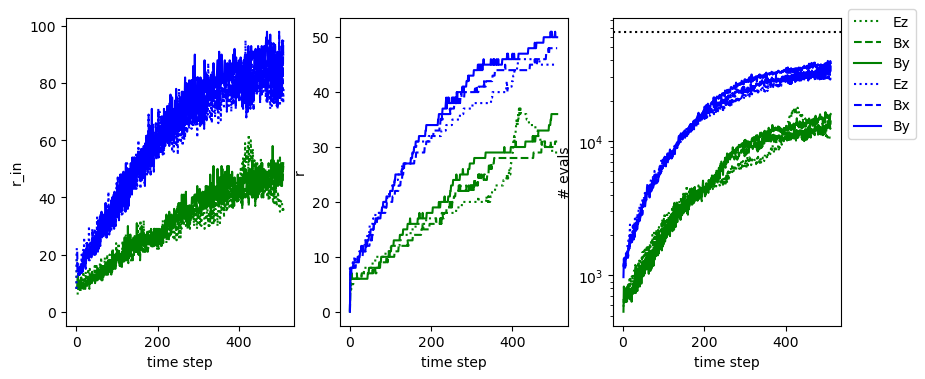

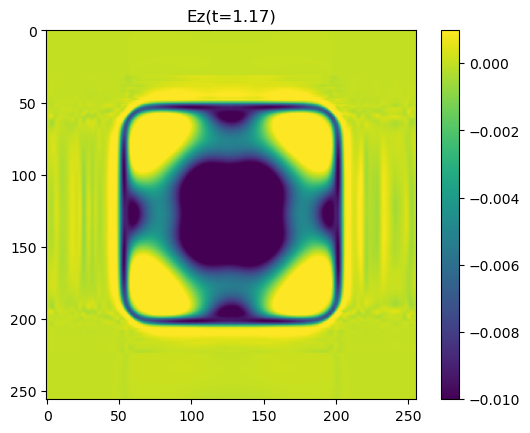

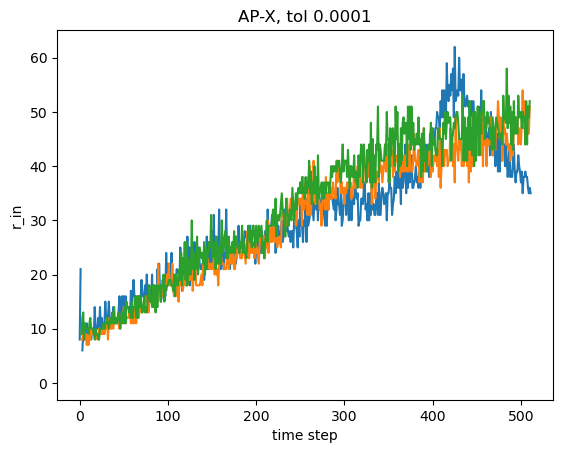

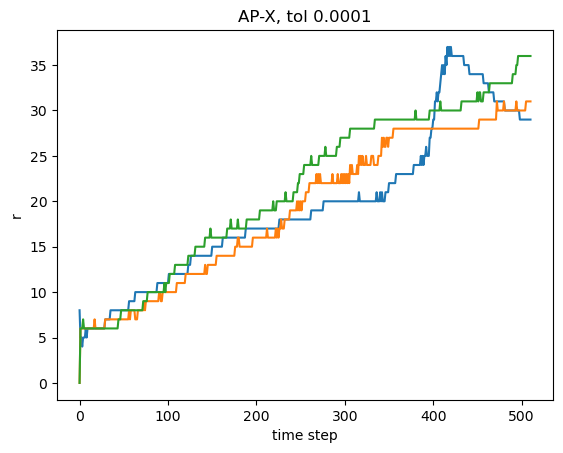

In [42]:
fig1, ax1 = plt.subplots(1, 3, figsize=(10,4))
colors = ['green', 'blue']

for it, tol in enumerate([1.0e-4, 1.0e-8]):
    Ez_data_ts, (r_in_Es, r_in_Bs, r_Es, r_Bs, num_evals_Es, num_evals_Bs) = run_maxwell(441, tol=tol)

    ax1[0].plot(r_in_Es[:, 2], color=colors[it], ls=':', label='Ez')
    ax1[0].plot(r_in_Bs[:, 0], color=colors[it], ls='--', label='Bx')
    ax1[0].plot(r_in_Bs[:, 1], color=colors[it], ls='-', label='By')

    ax1[1].plot(r_Es[:, 2], color=colors[it], ls=':', label='Ez')
    ax1[1].plot(r_Bs[:, 0], color=colors[it], ls='--', label='Bx')
    ax1[1].plot(r_Bs[:, 1], color=colors[it], ls='-', label='By')

    ax1[2].semilogy(num_evals_Es[:, 2], color=colors[it], ls=':', label='Ez')
    ax1[2].semilogy(num_evals_Bs[:, 0], color=colors[it], ls='--', label='Bx')
    ax1[2].semilogy(num_evals_Bs[:, 1], color=colors[it], ls='-', label='By')

    if it == 0:
        plt.figure()
        # plt.imshow(Ez_data_ts[0])
        # plt.title('Ez(t=0.9)')
        plt.imshow(Ez_data_ts[1], vmax=0.001, vmin=-0.01)
        plt.title('Ez(t=1.17)')
        # plt.imshow(Ez_data_ts[2])
        # plt.title('Ez(t=1.5)')
        plt.colorbar()
        
        plt.figure()
        plt.plot(r_in_Es[:,2], label='Ez')
        plt.plot(r_in_Bs[:,0], label='Bx')
        plt.plot(r_in_Bs[:,1], label='By')
        plt.ylabel('r_in')
        plt.xlabel('time step')
        plt.title(f'AP-X, tol {tol}')
        
        plt.figure()
        plt.plot(r_Es[:,2], label='Ez')
        plt.plot(r_Bs[:,0], label='Bx')
        plt.plot(r_Bs[:,1], label='By')
        plt.ylabel('r')
        plt.xlabel('time step')
        plt.title(f'AP-X, tol {tol}')


ax1[2].axhline(q**(L*2), color='k', ls=':')
ax1[0].set_xlabel('time step')
ax1[0].set_ylabel('r_in')
ax1[1].set_xlabel('time step')
ax1[1].set_ylabel('r')
ax1[2].set_xlabel('time step')
ax1[2].set_ylabel('# evals')
ax1[2].legend(bbox_to_anchor=(1.0,1.05), loc='upper left')


plt.show()


run maxwell: tol 0.0001 DMAX None
run maxwell: tol 1e-08 DMAX None


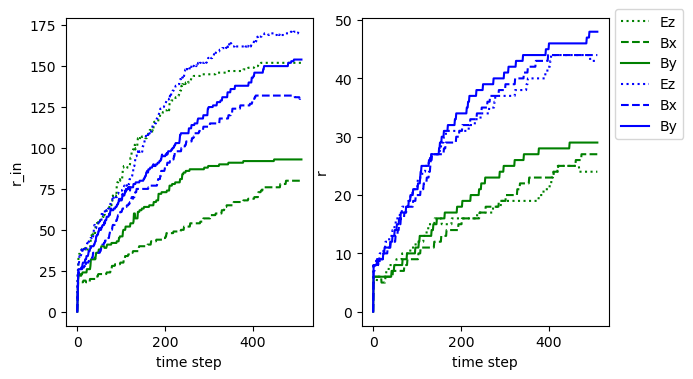

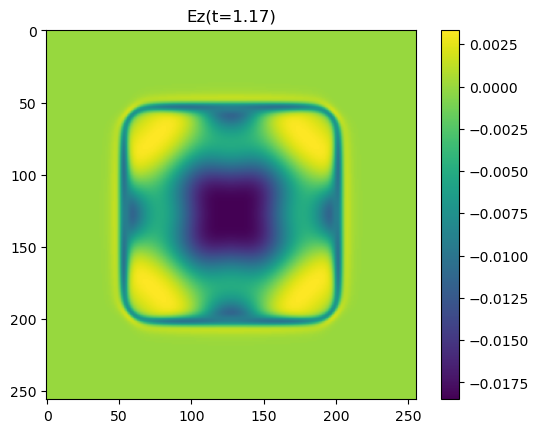

In [29]:
fig1, ax1 = plt.subplots(1, 2, figsize=(7,4))
colors = ['green', 'blue']

for it, tol in enumerate([1.0e-4, 1.0e-8]):
    Ez_data_ts, (r_in_Es, r_in_Bs, r_Es, r_Bs, num_evals_E, num_evals_B) = run_maxwell(1, tol=tol)

    ax1[0].plot(r_in_Es[:,2], color=colors[it], ls=':', label='Ez')
    ax1[0].plot(r_in_Bs[:,0], color=colors[it], ls='--', label='Bx')
    ax1[0].plot(r_in_Bs[:,1], color=colors[it], ls='-', label='By')

    ax1[1].plot(r_Es[:,2], color=colors[it], ls=':', label='Ez')
    ax1[1].plot(r_Bs[:,0], color=colors[it], ls='--', label='Bx')
    ax1[1].plot(r_Bs[:,1], color=colors[it], ls='-', label='By')

ax1[0].set_xlabel('time step')
ax1[0].set_ylabel('r_in')
ax1[1].set_xlabel('time step')
ax1[1].set_ylabel('r')
ax1[1].legend(bbox_to_anchor=(1.0,1.05), loc='upper left')

plt.figure()
# plt.imshow(Ez_data_ts[0])
# plt.title('Ez(t=0.9)')
plt.imshow(Ez_data_ts[1])
plt.title('Ez(t=1.17)')
# plt.imshow(Ez_data_ts[2])
# plt.title('Ez(t=1.5)')
plt.colorbar()

plt.show()



run maxwell: tol 0.0001 DMAX None


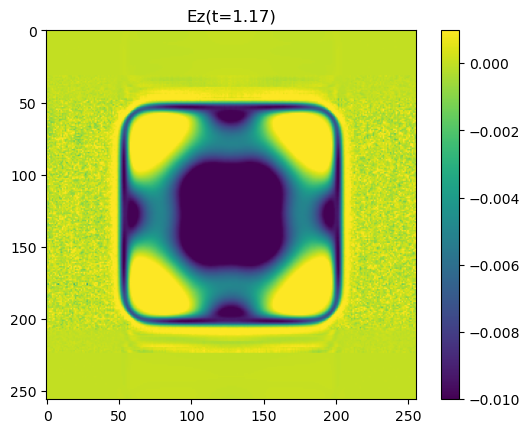

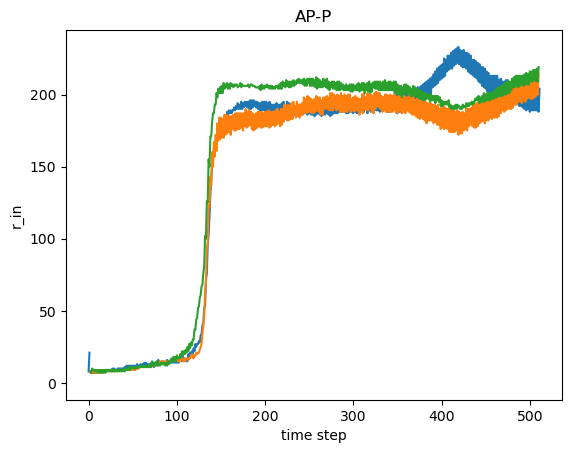

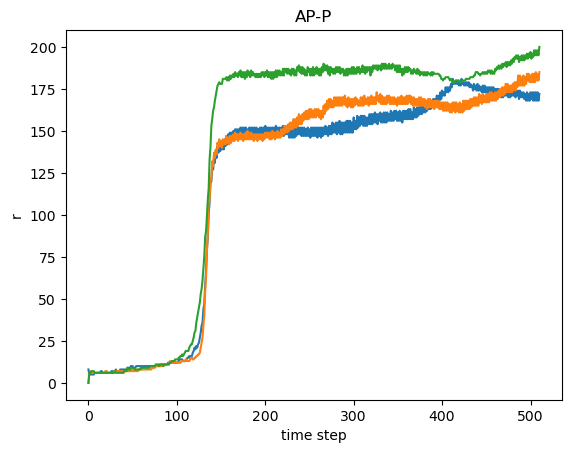

In [39]:
### AP-P test ### 

Ez_data_ts, (r_in_Es, r_in_Bs, r_Es, r_Bs, num_evals_Es, num_evals_Bs) = run_maxwell(771, tol=1.0e-4)

plt.figure()
# plt.imshow(Ez_data_ts[0])
# plt.title('Ez(t=0.9)')
plt.imshow(Ez_data_ts[1], vmax=0.001, vmin=-0.01)
plt.title('Ez(t=1.17)')
# plt.imshow(Ez_data_ts[2])
# plt.title('Ez(t=1.5)')
plt.colorbar()

plt.figure()
plt.plot(r_in_Es[:,2], label='Ez')
plt.plot(r_in_Bs[:,0], label='Bx')
plt.plot(r_in_Bs[:,1], label='By')
plt.ylabel('r_in')
plt.xlabel('time step')
plt.title('AP-P')

plt.figure()
plt.plot(r_Es[:,2], label='Ez')
plt.plot(r_Bs[:,0], label='Bx')
plt.plot(r_Bs[:,1], label='By')
plt.ylabel('r')
plt.xlabel('time step')
plt.title('AP-P')

plt.show()


run maxwell: tol 0.0001 DMAX None


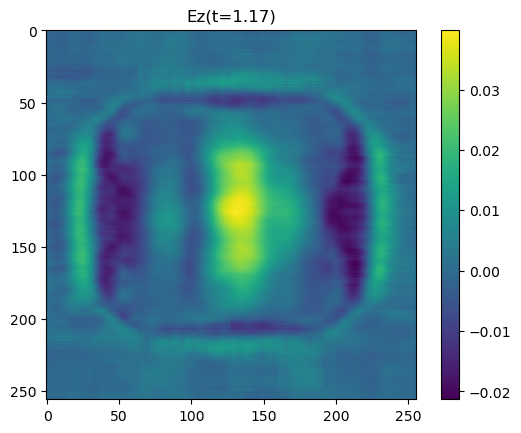

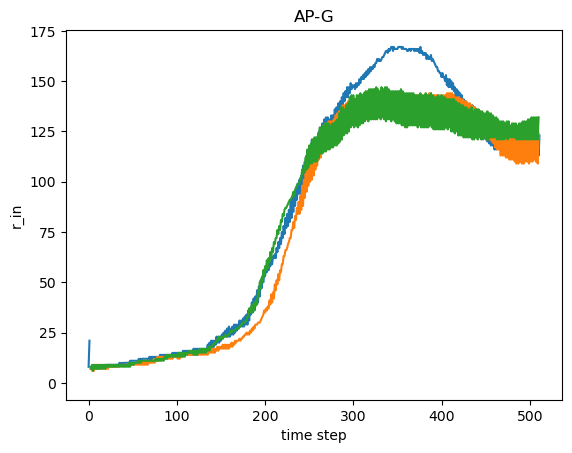

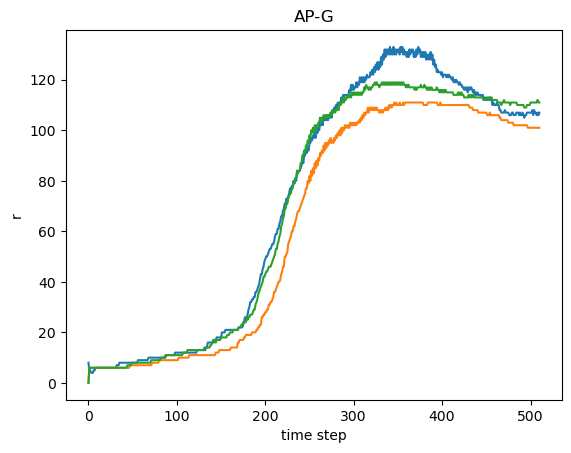

In [40]:
### AP-G test ### 

Ez_data_ts, (r_in_Es, r_in_Bs, r_Es, r_Bs, num_evals_Es, num_evals_Bs) = run_maxwell(331, tol=1.0e-4)

plt.figure()
# plt.imshow(Ez_data_ts[0])
# plt.title('Ez(t=0.9)')
plt.imshow(Ez_data_ts[1])
plt.title('Ez(t=1.17)')
# plt.imshow(Ez_data_ts[2])
# plt.title('Ez(t=1.5)')
plt.colorbar()

plt.figure()
plt.plot(r_in_Es[:,2], label='Ez')
plt.plot(r_in_Bs[:,0], label='Bx')
plt.plot(r_in_Bs[:,1], label='By')
plt.ylabel('r_in')
plt.xlabel('time step')
plt.title('AP-G')

plt.figure()
plt.plot(r_Es[:,2], label='Ez')
plt.plot(r_Bs[:,0], label='Bx')
plt.plot(r_Bs[:,1], label='By')
plt.ylabel('r')
plt.xlabel('time step')
plt.title('AP-G')

plt.show()
